In [38]:
%load_ext autoreload
%autoreload 2

In [39]:
import pandas as pd
import numpy as np
import os
import sys
sys.path.append('../core')
import config
import model_func

In [ ]:
structured_file = os.path.join(config.raw_data_path, 'ami_cohort_structured_features.csv')


In [6]:
df = pd.read_csv(structured_file)
df.shape

(40465, 25)

In [7]:
df.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'gender',
       'anchor_age', 'anchor_year', 'anchor_year_group', 'dod',
       'admission_age', 'CK_MB_max', 'BNP_max', 'Troponin_T_max'],
      dtype='object')

Target Variable

In [8]:
y = df['hospital_expire_flag']

drop leakable or ID columns

In [9]:
X = df.drop(columns=[
    'hospital_expire_flag', 
    'deathtime',            
    'discharge_location',   
    'dod',                  
    'subject_id',          
    'hadm_id',              
    'admittime',           
    'dischtime',       
    'anchor_year',        
    'anchor_year_group',  
    'edregtime',        
    'edouttime'     
])

In [10]:
X.shape

(40465, 13)

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40465 entries, 0 to 40464
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   admission_type      40465 non-null  object 
 1   admit_provider_id   40465 non-null  object 
 2   admission_location  40465 non-null  object 
 3   insurance           40204 non-null  object 
 4   language            40371 non-null  object 
 5   marital_status      38851 non-null  object 
 6   race                40465 non-null  object 
 7   gender              40465 non-null  object 
 8   anchor_age          40465 non-null  int64  
 9   admission_age       40465 non-null  int64  
 10  CK_MB_max           13913 non-null  float64
 11  BNP_max             1844 non-null   float64
 12  Troponin_T_max      12716 non-null  float64
dtypes: float64(3), int64(2), object(8)
memory usage: 4.0+ MB


In [12]:
numeric_features = [
    'anchor_age', 'admission_age',
    'CK_MB_max', 'BNP_max', 'Troponin_T_max'
]

categorical_features = [
    'admission_type', 'admit_provider_id', 'admission_location',
    'insurance', 'language', 'marital_status', 'race', 'gender'
]

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Fill missing numerical values and scale numeric features

In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Fill missing categorical features and one hot encode categorical features into numerical features

In [16]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

## Split Data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")

  X_train shape: (32372, 13)
  y_train shape: (32372,)
  X_test shape: (8093, 13)
  y_test shape: (8093,)


preprocess training data

In [20]:
preprocessor.fit(X_train)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [21]:
X_train

,admission_type,admit_provider_id,admission_location,insurance,language,marital_status,race,gender,anchor_age,admission_age,CK_MB_max,BNP_max,Troponin_T_max
11607,EW EMER.,P127QK,EMERGENCY ROOM,Private,English,MARRIED,WHITE,F,54,54,NaN,NaN,NaN
38943,EW EMER.,P00HGT,EMERGENCY ROOM,Medicare,English,MARRIED,WHITE,M,75,77,3.0,NaN,NaN
26710,EW EMER.,P63MXO,WALK-IN/SELF REFERRAL,Private,English,MARRIED,WHITE,M,60,60,2.0,NaN,NaN
20116,DIRECT OBSERVATION,P76901,PHYSICIAN REFERRAL,Medicare,English,MARRIED,WHITE,M,75,75,NaN,NaN,NaN
5647,EW EMER.,P32TVU,TRANSFER FROM HOSPITAL,Private,English,MARRIED,WHITE,F,57,63,NaN,NaN,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13224,EW EMER.,P0964Y,EMERGENCY ROOM,Medicare,English,MARRIED,WHITE,M,61,68,NaN,NaN,NaN
33815,EU OBSERVATION,P73VYB,TRANSFER FROM SKILLED NURSING FACILITY,Medicare,Chinese,WIDOWED,ASIAN,F,91,91,NaN,NaN,NaN
24981,DIRECT OBSERVATION,P250TS,TRANSFER FROM HOSPITAL,Medicare,English,SINGLE,WHITE,M,59,59,NaN,NaN,NaN
12492,EW EMER.,P43MIV,EMERGENCY ROOM,Medicare,English,MARRIED,WHITE,M,70,74,NaN,NaN,NaN


## Model - Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import joblib
import os

In [25]:
model_baseline_logistic = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('classifier', LogisticRegression(
        random_state=42, class_weight='balanced', max_iter=1000))
])

In [26]:
model_baseline_logistic.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
import importlib
importlib.reload(model_func)

<module 'model_func' from 'e:\\IIT\\IRP\\notebooks\\../core\\model_func.py'>

In [47]:
model_func.save_model('model_baseline_logistic', model_baseline_logistic, 'baseline')

Model saved successfully at: E:\IIT\IRP\results\models\baseline\model_baseline_logistic.joblib


### Evaluation - logistic

In [48]:
y_pred = model_baseline_logistic.predict(X_test)
y_pred_proba = model_baseline_logistic.predict_proba(X_test)[:, 1]

In [56]:
auc_val = roc_auc_score(y_test, y_pred_proba)
print(f"  Area Under the Curve (AUC): {auc:.4f}")

f1_val = f1_score(y_test, y_pred)
print(f"  F1-Score: {f1:.4f}")

  Area Under the Curve (AUC): 0.7818
  F1-Score: 0.2098


In [61]:
report_str = classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)'])
model_func.save_report('baseline_logistic', report_str, 'baseline/baseline_logistic', auc=auc_val, f1=f1_val)

print(report_str)

Report saved successfully at: E:\IIT\IRP\results\metrics\baseline/baseline_logistic\baseline_logistic.txt
              precision    recall  f1-score   support

Survived (0)       0.98      0.76      0.86      7688
    Died (1)       0.13      0.64      0.21       405

    accuracy                           0.76      8093
   macro avg       0.55      0.70      0.53      8093
weighted avg       0.93      0.76      0.82      8093



Figure saved successfully at: E:\IIT\IRP\results\figures\baseline/baseline_logistic\baseline_logistic_confusion_matrix.png


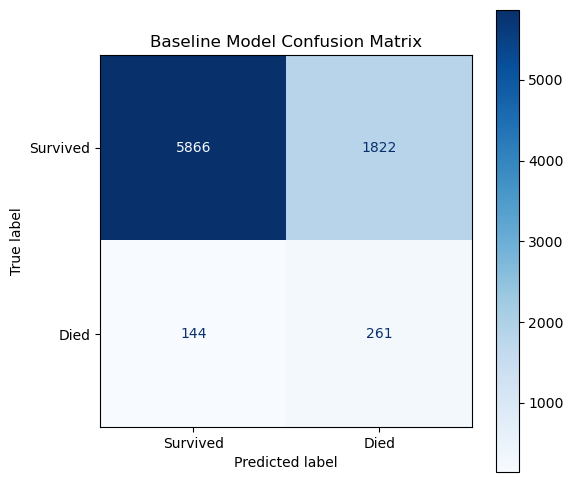

In [63]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(model_baseline_logistic, X_test, y_test,
                                      ax=ax, cmap='Blues',
                                      display_labels=['Survived', 'Died'])
plt.title('Baseline Model Confusion Matrix')
model_func.save_figure('baseline_logistic', fig, 'baseline/baseline_logistic', filename_suffix='confusion_matrix')
plt.show()

## Model - Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, f1_score
import matplotlib.pyplot as plt

In [65]:
model_baseline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',  
        n_jobs=-1 
    ))
])

In [66]:
model_baseline_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
model_func.save_model('model_baseline_random_forest', model_baseline_rf, 'baseline')

Model saved successfully at: E:\IIT\IRP\results\models\baseline\model_baseline_random_forest.joblib


In [67]:
y_pred_rf = model_baseline_rf.predict(X_test)
y_pred_proba_rf = model_baseline_rf.predict_proba(X_test)[:, 1]

In [68]:
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"  Area Under the Curve (AUC): {auc_rf:.4f}")

f1_rf = f1_score(y_test, y_pred_rf)
print(f"  F1-Score (for Died): {f1_score(y_test, y_pred_rf, pos_label=1):.4f}")

  Area Under the Curve (AUC): 0.7525
  F1-Score (for Died): 0.0239


In [70]:
report_str = classification_report(y_test, y_pred_rf, target_names=['Survived (0)', 'Died (1)'])

model_func.save_report('baseline_random_forest', report_str, 'baseline/baseline_random_forest', auc=auc_rf, f1=f1_rf)

print(report_str)

Report saved successfully at: E:\IIT\IRP\results\metrics\baseline/baseline_random_forest\baseline_random_forest.txt
              precision    recall  f1-score   support

Survived (0)       0.95      1.00      0.97      7688
    Died (1)       0.36      0.01      0.02       405

    accuracy                           0.95      8093
   macro avg       0.65      0.51      0.50      8093
weighted avg       0.92      0.95      0.93      8093



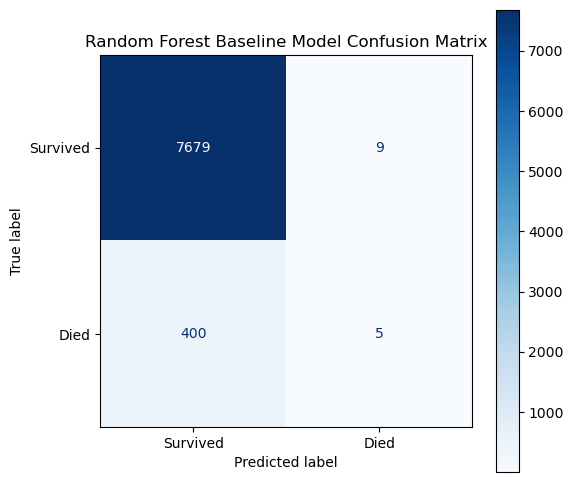

Figure saved successfully at: E:\IIT\IRP\results\figures\baseline/baseline_random_forest\baseline_random_forest_confusion_matrix.png


In [72]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(model_baseline_rf, X_test, y_test,
                                      ax=ax, cmap='Blues',
                                      display_labels=['Survived', 'Died'])
plt.title('Random Forest Baseline Model Confusion Matrix')
plt.show()

model_func.save_figure('baseline_random_forest', fig, 'baseline/baseline_random_forest', filename_suffix='confusion_matrix')